### Extracción señal BOLD:

Atlas Seitzman


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import os
import seaborn as sns

EXPLORANDO DATOS - SERIES DE TIEMPO - npz files


In [2]:
data_npz_AD = np.load("DATA/seitzman_brain_parcelations_files_npz/ts_AD_seitzman_adni_oasis_matchit.npz", allow_pickle=True)
data_npz_CNAD = np.load("DATA/seitzman_brain_parcelations_files_npz/ts_CNAD_seitzman_adni_oasis_matchit.npz", allow_pickle=True)
data_npz_CNMCI = np.load("DATA/seitzman_brain_parcelations_files_npz/ts_CNMCI_seitzman_adni_oasis_matchit.npz", allow_pickle=True)
data_npz_MCI = np.load("DATA/seitzman_brain_parcelations_files_npz/ts_MCI_seitzman_adni_oasis_matchit.npz", allow_pickle=True)

print (data_npz_AD)
array_names = data_npz_CNMCI.files; print(array_names)

NpzFile 'DATA/seitzman_brain_parcelations_files_npz/ts_AD_seitzman_adni_oasis_matchit.npz' with keys: data, subjects_ts, roi_img, labels, masker_type
['data', 'subjects_ts', 'roi_img', 'labels', 'masker_type']


'data' = Directorios de los datos

'subjects_ts' = time series

'roi_img'

'labels' = roi #

'masker_type'

In [3]:
print(len(data_npz_AD['subjects_ts']), len(data_npz_CNAD['subjects_ts']), len(data_npz_MCI['subjects_ts']),len(data_npz_CNMCI['subjects_ts']))
print(data_npz_AD['subjects_ts'][0].shape,data_npz_AD['subjects_ts'][62].shape)
print(data_npz_CNAD['subjects_ts'][0].shape, data_npz_CNAD['subjects_ts'][63].shape)
print(data_npz_MCI['subjects_ts'][0].shape, data_npz_MCI['subjects_ts'][57].shape)
print(data_npz_CNMCI['subjects_ts'][0].shape, data_npz_CNMCI['subjects_ts'][57].shape)

#print(data_npz_AD['subjects_ts'][0],data_npz_CNAD['subjects_ts'][0],data_npz_MCI['subjects_ts'][0],data_npz_CNMCI['subjects_ts'][0])
print(data_npz_AD['masker_type'],data_npz_CNAD['masker_type'],data_npz_MCI['masker_type'],data_npz_CNMCI['masker_type'])


63 64 58 58
(197, 300) (164, 300)
(200, 300) (164, 300)
(197, 300) (197, 300)
(197, 300) (164, 300)
Spheres Spheres Spheres Spheres


In [4]:
print(data_npz_AD['data'][0]+"\n",data_npz_AD['data'][62])

print(data_npz_CNAD['roi_img'].shape)

print(data_npz_MCI['masker_type'])

print(data_npz_MCI['labels'][0], data_npz_MCI['labels'][299])

D:/neuroengineering_master/master_DB/DB_ADNI/ADNI_DB/data/derivatives/AD/sub-S0150/func/sub-S0150_task-rest_bold.nii
 D:/neuroengineering_master/master_DB/DB_OASIS/OASIS_DB/data/BIDS/AD/sub-OAS31139/func/dswausub-OAS31139_ses-d0533_task-rest_run-02_bold.nii
(300, 3)
Spheres
roi 0 roi 299


In [5]:
data_npz_AD['subjects_ts'][0].shape 

(197, 300)

In [6]:
'''global_signals_subjects(array): parcelled (structural or functional) time series. Shape --> (n, time_series, ROIs)
        TR(int): fMRI acquisition repetition time'''
# for n in range(len(data_npz_AD['subjects_ts'])):
#         print(n)
#         mi_array = np.array([n, data_npz_AD['subjects_ts'][n]])

'global_signals_subjects(array): parcelled (structural or functional) time series. Shape --> (n, time_series, ROIs)\n        TR(int): fMRI acquisition repetition time'

* (-) SEPARAR DATOS POR NUMERO DE SERIES TEMPORALES Y GRUPO COGNITIVO EN ARRAYS

In [7]:
# Create an empty list to store the subject arrays
subjects_list = []

# Define the expected shape for each subject's data

#expected_shape = (164, 300)
#expected_shape = (197, 300)
expected_shape = (200, 300)

# Iterate through each subject and check its shape before appending
for i in range(len(data_npz_AD['subjects_ts'])):
    subject_data = data_npz_AD['subjects_ts'][i]
    
    # Check if the subject's data is a numpy array and has the correct shape
    if isinstance(subject_data, np.ndarray) and subject_data.shape == expected_shape:
        subjects_list.append(subject_data)
    else:
        # This part handles the error, for example, by printing a message
        print(f"Skipping subject at index {i} due to incorrect shape: {subject_data.shape}")

# Now, convert the filtered list to a NumPy array

#array_AD_164 = np.array(subjects_list)
#array_AD_197 = np.array(subjects_list)
array_AD_200 = np.array(subjects_list)

# Verify the final shape of the array
#print(final_array_AD.shape)

Skipping subject at index 0 due to incorrect shape: (197, 300)
Skipping subject at index 1 due to incorrect shape: (197, 300)
Skipping subject at index 2 due to incorrect shape: (197, 300)
Skipping subject at index 3 due to incorrect shape: (197, 300)
Skipping subject at index 6 due to incorrect shape: (197, 300)
Skipping subject at index 7 due to incorrect shape: (197, 300)
Skipping subject at index 8 due to incorrect shape: (197, 300)
Skipping subject at index 9 due to incorrect shape: (197, 300)
Skipping subject at index 10 due to incorrect shape: (197, 300)
Skipping subject at index 11 due to incorrect shape: (197, 300)
Skipping subject at index 12 due to incorrect shape: (197, 300)
Skipping subject at index 13 due to incorrect shape: (197, 300)
Skipping subject at index 16 due to incorrect shape: (197, 300)
Skipping subject at index 17 due to incorrect shape: (197, 300)
Skipping subject at index 18 due to incorrect shape: (197, 300)
Skipping subject at index 21 due to incorrect sh

In [9]:
subjects_list = []

#expected_shape = (164, 300)
#expected_shape = (197, 300)
expected_shape = (200, 300)

# Iterate through each subject and check its shape before appending
for i in range(len(data_npz_CNAD['subjects_ts'])):                                                ### CAMBIAR GRUPO ############
    subject_data = data_npz_CNAD['subjects_ts'][i]                                                ### CAMBIAR GRUPO ############
    if isinstance(subject_data, np.ndarray) and subject_data.shape == expected_shape:
        subjects_list.append(subject_data)
    else:
        # This part handles the error, for example, by printing a message
        print(f"Skipping subject at index {i} due to incorrect shape: {subject_data.shape}")

#array_CNAD_164 = np.array(subjects_list)                                                ### CAMBIAR GRUPO ############
#array_CNAD_197 = np.array(subjects_list)           
array_CNAD_200 = np.array(subjects_list)                                                ### CAMBIAR GRUPO ############

Skipping subject at index 1 due to incorrect shape: (197, 300)
Skipping subject at index 2 due to incorrect shape: (197, 300)
Skipping subject at index 3 due to incorrect shape: (197, 300)
Skipping subject at index 4 due to incorrect shape: (197, 300)
Skipping subject at index 5 due to incorrect shape: (197, 300)
Skipping subject at index 6 due to incorrect shape: (197, 300)
Skipping subject at index 7 due to incorrect shape: (197, 300)
Skipping subject at index 8 due to incorrect shape: (197, 300)
Skipping subject at index 9 due to incorrect shape: (197, 300)
Skipping subject at index 12 due to incorrect shape: (197, 300)
Skipping subject at index 13 due to incorrect shape: (197, 300)
Skipping subject at index 14 due to incorrect shape: (197, 300)
Skipping subject at index 17 due to incorrect shape: (197, 300)
Skipping subject at index 18 due to incorrect shape: (197, 300)
Skipping subject at index 20 due to incorrect shape: (197, 300)
Skipping subject at index 21 due to incorrect sha

AUTOMATIZAR EL PROCESO ANTERIOR


In [11]:
# Lista de las formas esperadas para los datos
expected_shapes = [(164, 300), (197, 300), (200, 300)]

# Diccionario con todos los grupos de datos
groups_to_process = {
    'AD': data_npz_AD,
    'CNAD': data_npz_CNAD,
    'MCI': data_npz_MCI,
    'CNMCI': data_npz_CNMCI
}
# Iteramos sobre cada forma esperada
for expected_shape in expected_shapes:
    print(f"--- Procesando con la forma: {expected_shape} ---")

    # Iteramos sobre cada grupo de datos
    for group_name, data in groups_to_process.items():
        subjects_list = []       

        for i, subject_data in enumerate(data['subjects_ts']):
            # Verificamos la forma de los datos
            if isinstance(subject_data, np.ndarray) and subject_data.shape == expected_shape:
                subjects_list.append(subject_data)
        
        # Creamos el nombre de la variable de salida
        shape_str = f"_{expected_shape[0]}"  # Ejemplo: "_164"
        output_var_name = f"array_{group_name}{shape_str}"

        # Convertimos la lista a un array de NumPy y lo asignamos a una variable global
        if subjects_list: # Solo creamos el array si la lista no está vacía
            globals()[output_var_name] = np.array(subjects_list)
            print(f"✔️ Creado '{output_var_name}' con {len(subjects_list)} sujetos.")
        else:
            print(f"⚠️ No se encontraron sujetos con la forma {expected_shape} para el grupo {group_name}. No se creó el array.")  
    print("\n")


--- Procesando con la forma: (164, 300) ---
✔️ Creado 'array_AD_164' con 36 sujetos.
✔️ Creado 'array_CNAD_164' con 30 sujetos.
⚠️ No se encontraron sujetos con la forma (164, 300) para el grupo MCI. No se creó el array.
✔️ Creado 'array_CNMCI_164' con 20 sujetos.


--- Procesando con la forma: (197, 300) ---
✔️ Creado 'array_AD_197' con 21 sujetos.
✔️ Creado 'array_CNAD_197' con 26 sujetos.
✔️ Creado 'array_MCI_197' con 51 sujetos.
✔️ Creado 'array_CNMCI_197' con 29 sujetos.


--- Procesando con la forma: (200, 300) ---
✔️ Creado 'array_AD_200' con 6 sujetos.
✔️ Creado 'array_CNAD_200' con 8 sujetos.
✔️ Creado 'array_MCI_200' con 7 sujetos.
✔️ Creado 'array_CNMCI_200' con 9 sujetos.




In [12]:
array_AD_197.shape

(21, 197, 300)

IMPORTAR LOS ID DE CADA SUJETO

In [13]:
workpath_dir = "E:/ACTUAL/SEMILLERO-PAPER/Git-Hub/NeuroCo_Project/"

consolidate_file_matchit = "DATA/df_matchit_oasis_adni_organized_paths_1022025.csv"

df_matchit_oasis_adni = os.path.join(workpath_dir, consolidate_file_matchit)
df_matchit_oasis_adni = pd.read_csv(df_matchit_oasis_adni)
df_matchit_oasis_adni.head()


subjects_ids_all = df_matchit_oasis_adni.id.to_numpy()

subjects_ids_AD = subjects_ids_all[0:64]
subjects_ids_AD = np.delete(subjects_ids_AD, 44)

subjects_ids_CNAD = subjects_ids_all[64:128]
subjects_ids_CNMCI = subjects_ids_all[128:186]
subjects_ids_MCI = subjects_ids_all[186::]

In [14]:
subjects_ids_AD

array([  150,  1074,  2373,  4188,  4197,  4324,  4404,  6013,  6072,
        6100,  6142,  6252,  6264,  6303,  6389,  6549,  6585,  6592,
        6595,  6655,  6683,  6690,  6712,  6736,  6833,  6843,  6850,
       30064, 30076, 30100, 30124, 30150, 30202, 30214, 30217, 30226,
       30238, 30244, 30262, 30287, 30334, 30541, 30554, 30560, 30649,
       30702, 30734, 30744, 30785, 30886, 30892, 30893, 30899, 30976,
       31003, 31016, 31024, 31054, 31086, 31129, 31134, 31139, 31140])

IMPORTAR FUNCIÓN DE CÁLCULO DE COHERENCIA MULTIPAPER Y APLICARLO PARA CADA CONJUNTO DE ARRAYS

In [ ]:
from utils.connectivity_utils import coherence_multitaper

# Workpath dir - correlation matrices folder
corr_workpath = "correlation_matrices/coherence_multitaper/"

# Clinical groups in order that they appear
groups = ['AD', 'CNAD', 'CNMCI', 'MCI']
results_dict = {}  # 

In [16]:
array_modificado_AD_197 = np.delete(array_AD_197, 16, axis=0)
## DEL ARRAY ORIGINAL ELIMINAR EL 16° ELEMENTO - CORRUPTO
array_modificado_CNMCI_197 = np.delete(array_CNMCI_197, 8, axis=0)
## DEL ARRAY ORIGINAL ELIMINAR EL 8° ELEMENTO - CORRUPTO

In [17]:

# files per network definition
data_dict = {        
    'seitzman_164TS': {
        'AD': array_AD_164,
        'CNAD': array_CNAD_164,
        #'CNMCI': array_MCI_164,             ## No hay sujetos con 164 TS
        'MCI': array_CNMCI_164
    },
        'seitzman_197TS': {
        'AD': array_modificado_AD_197,
        'CNAD': array_CNAD_197,
        'CNMCI': array_modificado_CNMCI_197,
        'MCI': array_CNMCI_197
    },    
    'seitzman_200TS': {
        'AD': array_AD_200,
        'CNAD': array_CNAD_200,
        'CNMCI': array_MCI_200,
        'MCI': array_CNMCI_200
    },
}
labels_dict = {
    'AD': subjects_ids_AD,
    'CNAD': subjects_ids_CNAD,
    'CNMCI': subjects_ids_CNMCI,
    'MCI': subjects_ids_MCI
}
#TR = 3000ms
# Iterate in networks, groups, and dataseries

for network, groups in data_dict.items():
    for group, data_series in groups.items():
        save_path = os.path.join(corr_workpath, f'{network}/{group}/')
        labels = labels_dict[group]

        correlation_matrix, mean_corr_matrix = coherence_multitaper(
            data_series, TR=3
        )
        
        # Agrega los resultados al diccionario existente
        results_dict[f'{network}_{group}_mean_coh_multitaper_matrix'] = correlation_matrix  # mean
        results_dict[f'{network}_{group}_med_coh_multitaper_matrix'] = mean_corr_matrix     # median
        
        print(f'Processed {network} for group {group}')

print("Procesamiento completado. El diccionario de resultados contiene:")
print(results_dict.keys())

0
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
1
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
2
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
3
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
4
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
5
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
6
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
7
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
8
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
9
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
10
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
11
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
12
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
13
samples 164 regions 300
tdata shape:  (300, 7, 164)
(300, 300, 83)
14
samples 164 regions 300
tda

In [18]:
dict_keys = list(results_dict.keys())
dict_keys

['seitzman_164TS_AD_mean_coh_multitaper_matrix',
 'seitzman_164TS_AD_med_coh_multitaper_matrix',
 'seitzman_164TS_CNAD_mean_coh_multitaper_matrix',
 'seitzman_164TS_CNAD_med_coh_multitaper_matrix',
 'seitzman_164TS_MCI_mean_coh_multitaper_matrix',
 'seitzman_164TS_MCI_med_coh_multitaper_matrix',
 'seitzman_197TS_AD_mean_coh_multitaper_matrix',
 'seitzman_197TS_AD_med_coh_multitaper_matrix',
 'seitzman_197TS_CNAD_mean_coh_multitaper_matrix',
 'seitzman_197TS_CNAD_med_coh_multitaper_matrix',
 'seitzman_197TS_CNMCI_mean_coh_multitaper_matrix',
 'seitzman_197TS_CNMCI_med_coh_multitaper_matrix',
 'seitzman_197TS_MCI_mean_coh_multitaper_matrix',
 'seitzman_197TS_MCI_med_coh_multitaper_matrix',
 'seitzman_200TS_AD_mean_coh_multitaper_matrix',
 'seitzman_200TS_AD_med_coh_multitaper_matrix',
 'seitzman_200TS_CNAD_mean_coh_multitaper_matrix',
 'seitzman_200TS_CNAD_med_coh_multitaper_matrix',
 'seitzman_200TS_CNMCI_mean_coh_multitaper_matrix',
 'seitzman_200TS_CNMCI_med_coh_multitaper_matrix',
 '

In [24]:
print(results_dict['seitzman_164TS_AD_mean_coh_multitaper_matrix'][10].shape)
#print(results_dict)
print(results_dict['seitzman_164TS_AD_mean_coh_multitaper_matrix'].shape)
#results_dict['seitzman_164TS_AD_mean_coh_multitaper_matrix'][0]

(300, 300)
(36, 300, 300)


In [ ]:
# array1 = np.random.rand(10, 300, 300)
# array2 = np.random.rand(10, 300, 300)
# array3 = np.random.rand(10, 300, 300)

# array_vertical = np.concatenate((array1, array2,array3), axis=0)
# arr_promedio = np.mean(array_vertical, axis=0)
# arr_promedio.shape
# arr_promedio[0]

# array_vertical.shape

PROMEDIAR MATRICES DE CORRELACIÓN DE LAS DIFERENTES SERIES DE TIEMPO POR GRUPOS COGNITIVOS

In [25]:
vertical_array_AD = np.concatenate((results_dict['seitzman_164TS_AD_mean_coh_multitaper_matrix'], results_dict['seitzman_197TS_CNAD_mean_coh_multitaper_matrix'], results_dict['seitzman_200TS_CNMCI_mean_coh_multitaper_matrix']), axis=0)
matriz_promedio_AD = np.mean(vertical_array_AD, axis=0)

vertical_array_CNAD = np.concatenate((results_dict['seitzman_164TS_CNAD_mean_coh_multitaper_matrix'], results_dict['seitzman_197TS_AD_mean_coh_multitaper_matrix'], results_dict['seitzman_200TS_MCI_mean_coh_multitaper_matrix']), axis=0)
matriz_promedio_CNAD = np.mean(vertical_array_CNAD, axis=0)

vertical_array_CNMCI = np.concatenate((results_dict['seitzman_197TS_MCI_mean_coh_multitaper_matrix'], results_dict['seitzman_200TS_AD_mean_coh_multitaper_matrix']), axis=0)
matriz_promedio_CNMCI = np.mean(vertical_array_CNMCI, axis=0)

vertical_array_MCI = np.concatenate((results_dict['seitzman_164TS_MCI_mean_coh_multitaper_matrix'], results_dict['seitzman_197TS_AD_mean_coh_multitaper_matrix'], results_dict['seitzman_200TS_CNAD_mean_coh_multitaper_matrix']), axis=0)
matriz_promedio_MCI = np.mean(vertical_array_MCI, axis=0)

print(matriz_promedio_AD.shape, matriz_promedio_CNAD.shape, matriz_promedio_CNMCI.shape, matriz_promedio_MCI.shape)

(300, 300) (300, 300) (300, 300) (300, 300)


Guardar Matrices en formato .csv

In [26]:
# Convertir a DataFrame de pandas
df_1 = pd.DataFrame(matriz_promedio_AD)
df_2 = pd.DataFrame(matriz_promedio_CNAD)
df_3 = pd.DataFrame(matriz_promedio_CNMCI)
df_4 = pd.DataFrame(matriz_promedio_MCI)

# Guardar en archivos CSV
df_1.to_csv("matriz_AD.csv", index=False)
df_2.to_csv("matriz_CNAD.csv", index=False)
df_3.to_csv("matriz_CNMCI.csv", index=False)
df_4.to_csv("matriz_MCI.csv", index=False)

LEER Y VISUALIZAR MATRICES

In [2]:
import networkx as nx

Leyendo archivo: matriz_AD.csv
Detectadas 300 columnas en el archivo.


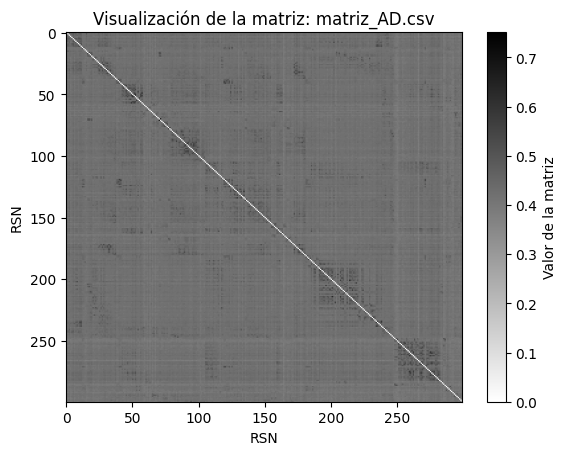

Leyendo archivo: matriz_CNAD.csv
Detectadas 300 columnas en el archivo.


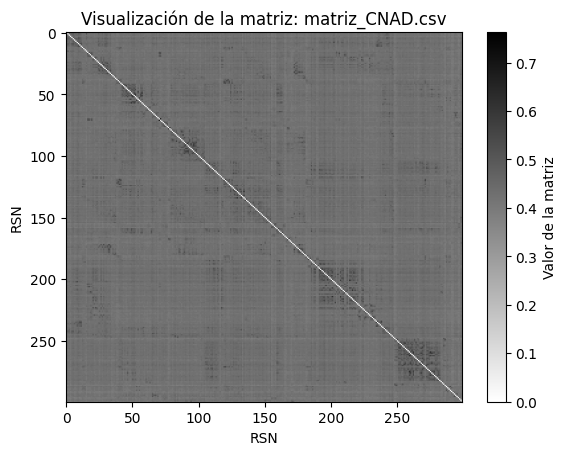

Leyendo archivo: matriz_CNMCI.csv
Detectadas 300 columnas en el archivo.


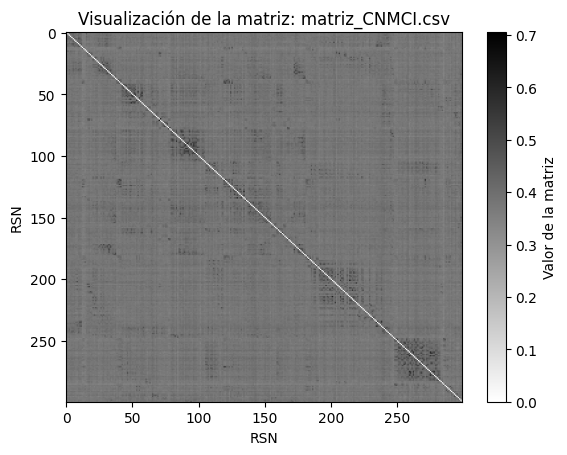

Leyendo archivo: matriz_MCI.csv
Detectadas 300 columnas en el archivo.


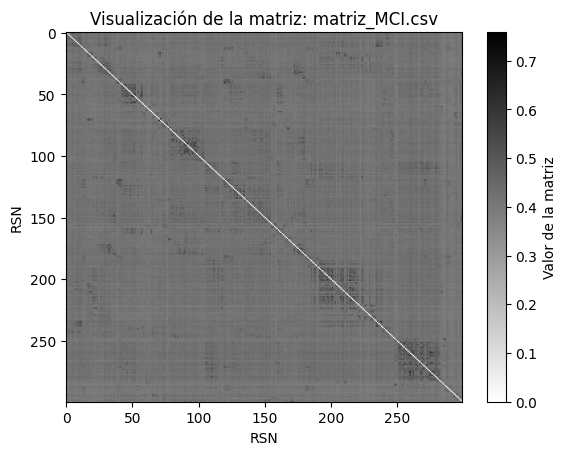

In [ ]:
# --- Configurar la ruta de  ---
carpeta_de_matrices = 'matrices'

# --- Leer y visualizar las matrices ---
if not os.path.isdir(carpeta_de_matrices):
    print(f"Error: La carpeta '{carpeta_de_matrices}' no se encontró.")
else:
    for nombre_archivo in os.listdir(carpeta_de_matrices):
        if nombre_archivo.endswith('.csv'):
            ruta_completa = os.path.join(carpeta_de_matrices, nombre_archivo)
            
            print(f"Leyendo archivo: {nombre_archivo}")
            
            try:
                # Paso 1: Leer el encabezado para obtener el número de columnas
                with open(ruta_completa, 'r') as f:
                    linea = next(f)
                    num_columnas = len(linea.strip().split(','))
                    
                print(f"Detectadas {num_columnas} columnas en el archivo.")
                
                # Paso 2: Cargar la matriz con la configuración correcta
                converters_dict = {
                    # Aquí está la corrección: ya no se necesita .decode()
                    i: lambda s: float(s.replace(',', '.')) 
                    for i in range(num_columnas)
                }

                matriz = np.genfromtxt(
                    ruta_completa,
                    delimiter=',', 
                    skip_header=1,
                    converters=converters_dict
                )
                
                # Visualizar la matriz
                plt.figure()
                plt.imshow(matriz, cmap='binary', aspect= 'auto') # 'Greys', 'binary' o 'bone', 'viridis', 'binary_r'
                plt.colorbar(label='Valor de la matriz')
                # plt.gca().invert_yaxis()
                plt.title(f'Visualización de la matriz: {nombre_archivo}')
                plt.xlabel('RSN')
                plt.ylabel('RSN')
                plt.show()
                
            except Exception as e:
                print(f"No se pudo procesar el archivo {nombre_archivo}. Error: {e}")

Prueba Grafos

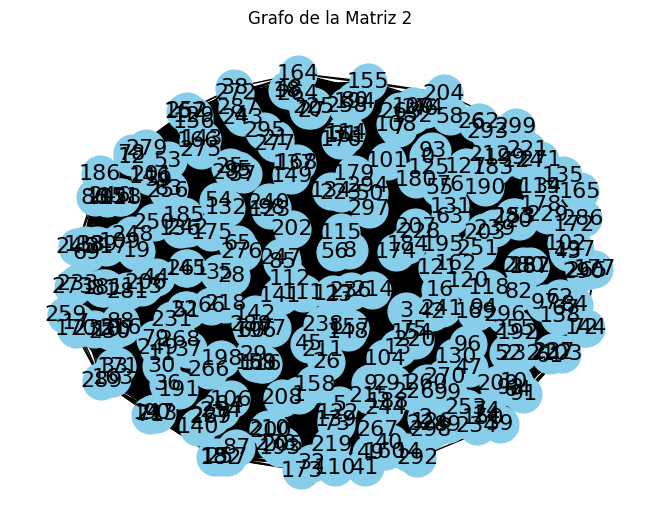

In [ ]:
# Convertir la matriz de adyacencia a un objeto de grafo
G = nx.from_numpy_array(matriz_promedio_AD)

# Dibujar el grafo
nx.draw(G, with_labels=True, node_color='skyblue', node_size=700, font_size=16)

# Mostrar el gráfico
plt.title("Grafo de la Matriz AD")
plt.show()